# 🔧 Step 2 — Health Indicator Construction + Stage Labeling

**Objective**: Extract multivariate features from raw vibration signals and automatically assign degradation stage labels (Stage 1: healthy, Stage 2: early degradation, Stage 3: near-failure) using health indicator thresholds.

This notebook produces:
- Multivariate feature matrix (20 features per time step per bearing)
- Scalar health indicator for stage boundary detection
- Automatic stage labels (FPT, acceleration point, EOL)
- Stage distribution across all 15 bearings
- Visualization of stages on HI trajectories

---
## 0. Setup

In [1]:
import os, sys, shutil

# ── Reset cwd first (avoids getcwd errors if a prior run
#    deleted the folder the kernel was sitting in) ─────────
os.chdir("/content")

# ── Clone repo (fresh every time) ─────────────────────────
REPO_PATH = "/content/RESS_2025_GAN_Conformal_RUL"
if os.path.exists(REPO_PATH):
    shutil.rmtree(REPO_PATH)
!git clone https://github.com/f-khadija-benzine/RESS_2025_GAN_Conformal_RUL.git {REPO_PATH}

os.chdir(REPO_PATH)
sys.path.insert(0, REPO_PATH)
sys.path.insert(0, f"{REPO_PATH}/src")

# ── Mount Google Drive ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Find XJTU-SY on Drive ────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEARCH_PATHS = [
    "/content/drive/MyDrive/datasets/XJTU-SY",
    "/content/drive/MyDrive/XJTU-SY",
    "/content/drive/MyDrive/data/XJTU-SY",
    "/content/drive/MyDrive/XJTU-SY_Bearing_Datasets",
    "/content/drive/MyDrive/datasets/XJTU-SY_Bearing_Datasets",
]
EXPECTED = {"35Hz12kN", "37.5Hz11kN", "40Hz10kN"}
DATA_ROOT = None
for p in SEARCH_PATHS:
    if os.path.exists(p):
        if EXPECTED.issubset(set(os.listdir(p))):
            DATA_ROOT = p
            break
        for sub in os.listdir(p):
            sp = os.path.join(p, sub)
            if os.path.isdir(sp) and EXPECTED.issubset(set(os.listdir(sp))):
                DATA_ROOT = sp
                break

from data_loader import XJTUSYLoader, OPERATING_CONDITIONS, CV_FOLDS, SAMPLING_RATE, SAMPLES_PER_FILE
from health_indicator import HealthIndicatorPipeline, get_all_feature_names

SAVE_DIR = f"{REPO_PATH}/results/figures"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"✅ Repo: {os.getcwd()}")
print(f"✅ DATA_ROOT: {DATA_ROOT}")
print("✅ All modules imported")

Cloning into '/content/RESS_2025_GAN_Conformal_RUL'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 114 (delta 50), reused 25 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (114/114), 2.90 MiB | 10.53 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Mounted at /content/drive
✅ Repo: /content/RESS_2025_GAN_Conformal_RUL
✅ DATA_ROOT: /content/drive/MyDrive/XJTU-SY_Bearing_Datasets
✅ All modules imported


---
## 1. Load all bearings

In [2]:
loader = XJTUSYLoader(DATA_ROOT)
all_data = loader.load_all(verbose=True)


=== Condition 1: 35.0 Hz, 12.0 kN ===
Loading Bearing1_1 (1-1): 123 recordings, failure mode: Outer race
  -> Shape: (123, 32768, 2), Memory: 32.2 MB
Loading Bearing1_2 (1-2): 161 recordings, failure mode: Outer race
  -> Shape: (161, 32768, 2), Memory: 42.2 MB
Loading Bearing1_3 (1-3): 158 recordings, failure mode: Outer race
  -> Shape: (158, 32768, 2), Memory: 41.4 MB
Loading Bearing1_4 (1-4): 122 recordings, failure mode: Cage
  -> Shape: (122, 32768, 2), Memory: 32.0 MB
Loading Bearing1_5 (1-5): 52 recordings, failure mode: Outer race + Ball
  -> Shape: (52, 32768, 2), Memory: 13.6 MB

=== Condition 2: 37.5 Hz, 11.0 kN ===
Loading Bearing2_1 (2-1): 491 recordings, failure mode: Inner race
  -> Shape: (491, 32768, 2), Memory: 128.7 MB
Loading Bearing2_2 (2-2): 161 recordings, failure mode: Outer race
  -> Shape: (161, 32768, 2), Memory: 42.2 MB
Loading Bearing2_3 (2-3): 533 recordings, failure mode: Cage
  -> Shape: (533, 32768, 2), Memory: 139.7 MB
Loading Bearing2_4 (2-4): 42 re

---
## 2. Process all bearings: extract features + assign stages

In [3]:
pipeline = HealthIndicatorPipeline(
    hi_method='simple_rms',       # simple RMS for stage detection
    smoothing_window=3,           # moving average window
    fpt_consecutive=2,            # 2 consecutive exceedances for FPT
    acceleration_sigma=1.0,       # sigma factor for acceleration point
)

results = pipeline.process_all(all_data, verbose=True)

Processing Bearing1_1...
  FPT: t=69 min [detected] | Acc: t=119 min | EOL: t=122 min
  Stages: S1=69, S2=50, S3=4
Processing Bearing1_2...
  FPT: t=35 min [detected] | Acc: t=118 min | EOL: t=160 min
  Stages: S1=35, S2=83, S3=43
Processing Bearing1_3...
  FPT: t=58 min [detected] | Acc: t=107 min | EOL: t=157 min
  Stages: S1=58, S2=49, S3=51
Processing Bearing1_4...
  FPT: t=83 min [detected] | Acc: t=104 min | EOL: t=121 min
  Stages: S1=83, S2=21, S3=18
Processing Bearing1_5...
  FPT: t=28 min [detected] | Acc: t=39 min | EOL: t=51 min
  Stages: S1=28, S2=11, S3=13
Processing Bearing2_1...
  FPT: t=452 min [detected] | Acc: t=474 min | EOL: t=490 min
  Stages: S1=452, S2=22, S3=17
Processing Bearing2_2...
  FPT: t=45 min [detected] | Acc: t=144 min | EOL: t=160 min
  Stages: S1=45, S2=99, S3=17
Processing Bearing2_3...
  FPT: t=127 min [detected] | Acc: t=336 min | EOL: t=532 min
  Stages: S1=127, S2=209, S3=197
Processing Bearing2_4...
  FPT: t=11 min [detected] | Acc: t=28 min |

---
## 3. Visualize stages for a sample bearing

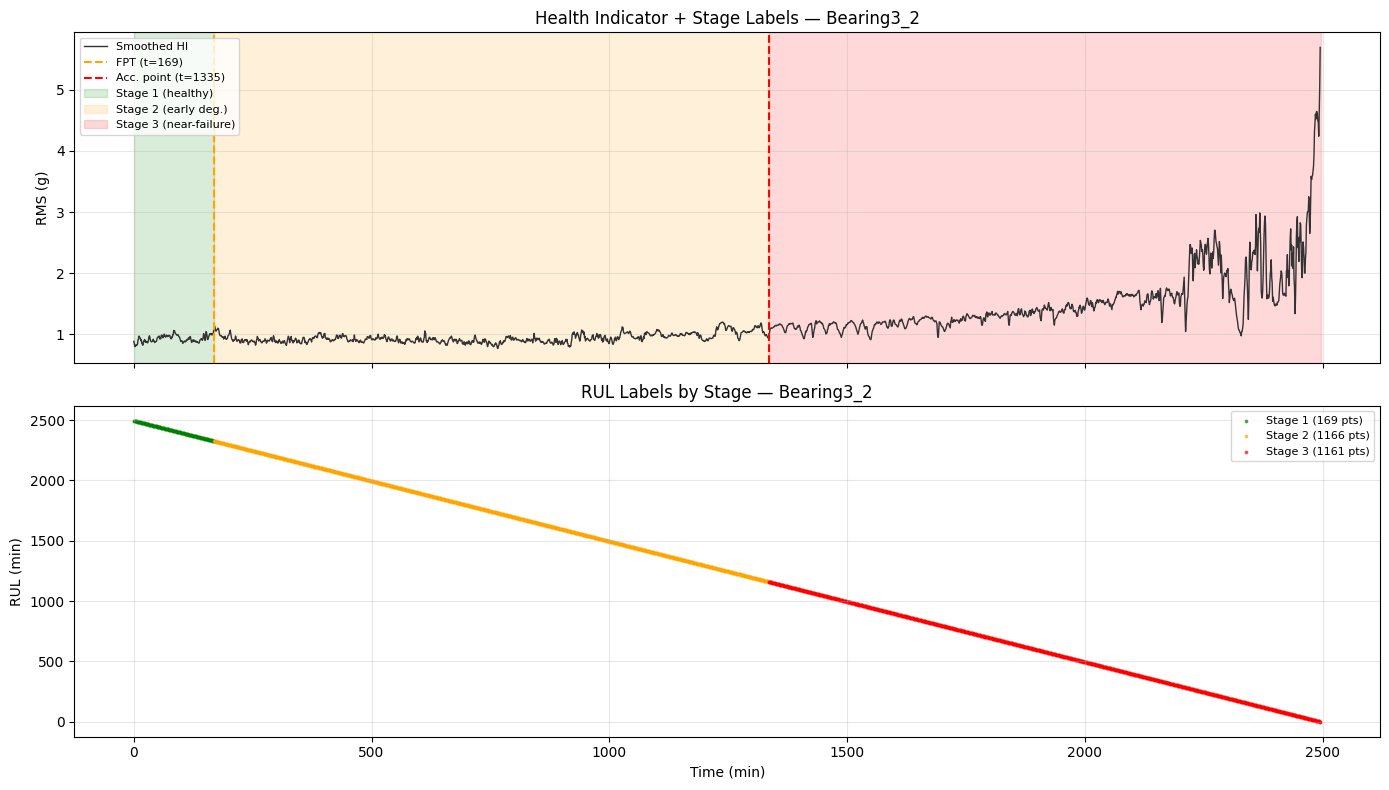

In [4]:
# Pick a bearing with a clear degradation trajectory
sample_bid = "Bearing3_2"
r = results[sample_bid]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

time = np.arange(len(r['hi_smoothed']))

# Plot 1: HI with stage boundaries
ax = axes[0]
ax.plot(time, r['hi_smoothed'], color='#333333', lw=1, label='Smoothed HI')
ax.axvline(r['fpt_idx'], color='orange', ls='--', lw=1.5, label=f"FPT (t={r['fpt_idx']})")
ax.axvline(r['acc_idx'], color='red', ls='--', lw=1.5, label=f"Acc. point (t={r['acc_idx']})")

# Color background by stage
ax.axvspan(0, r['fpt_idx'], alpha=0.15, color='green', label='Stage 1 (healthy)')
ax.axvspan(r['fpt_idx'], r['acc_idx'], alpha=0.15, color='orange', label='Stage 2 (early deg.)')
ax.axvspan(r['acc_idx'], len(time), alpha=0.15, color='red', label='Stage 3 (near-failure)')

ax.set_ylabel('RMS (g)')
ax.set_title(f'Health Indicator + Stage Labels — {sample_bid}')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: RUL with stage colors
ax2 = axes[1]
colors_stage = {1: 'green', 2: 'orange', 3: 'red'}
for stage in [1, 2, 3]:
    mask = r['stage_labels'] == stage
    ax2.scatter(time[mask], r['rul'][mask], c=colors_stage[stage], s=3, alpha=0.6,
                label=f'Stage {stage} ({r["stage_counts"][stage]} pts)')

ax2.set_xlabel('Time (min)')
ax2.set_ylabel('RUL (min)')
ax2.set_title(f'RUL Labels by Stage — {sample_bid}')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_stage_labels_sample.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Stage labels for all 15 bearings

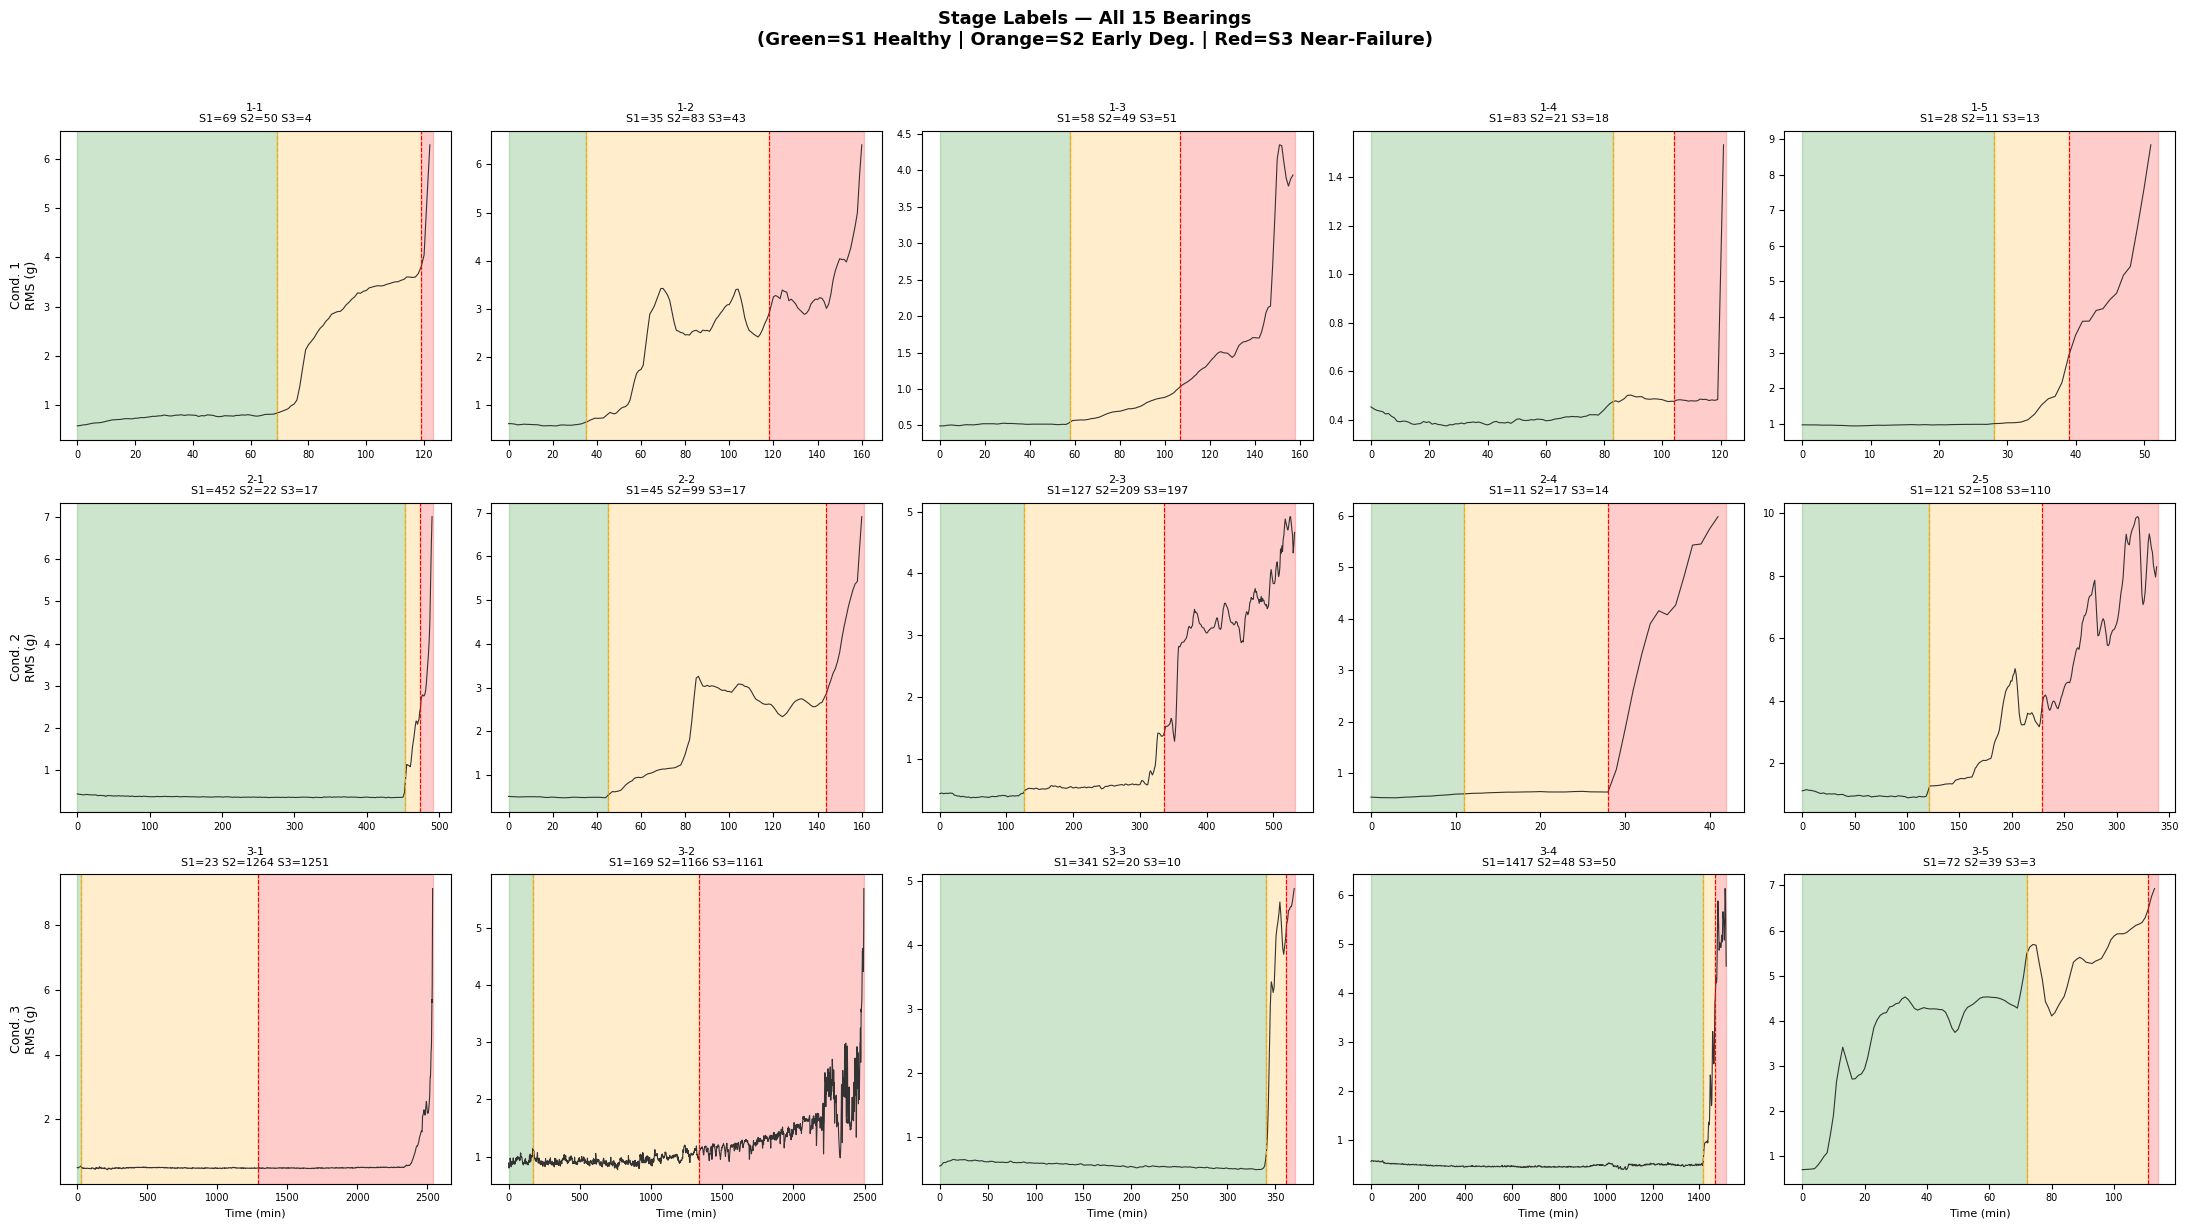

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
colors = {1: '#2196F3', 2: '#FF9800', 3: '#4CAF50'}

for cond in [1, 2, 3]:
    for j, bid in enumerate(OPERATING_CONDITIONS[cond]['bearings']):
        ax = axes[cond - 1, j]
        r = results[bid]
        time = np.arange(len(r['hi_smoothed']))

        # Plot HI
        ax.plot(time, r['hi_smoothed'], color='#333333', lw=0.8)

        # Color background by stage
        ax.axvspan(0, r['fpt_idx'], alpha=0.2, color='green')
        ax.axvspan(r['fpt_idx'], r['acc_idx'], alpha=0.2, color='orange')
        ax.axvspan(r['acc_idx'], len(time), alpha=0.2, color='red')

        # Mark boundaries
        ax.axvline(r['fpt_idx'], color='orange', ls='--', lw=0.8)
        ax.axvline(r['acc_idx'], color='red', ls='--', lw=0.8)

        sc = r['stage_counts']
        short_id = bid.replace('Bearing', '').replace('_', '-')
        ax.set_title(f'{short_id}\nS1={sc[1]} S2={sc[2]} S3={sc[3]}', fontsize=8)

        if j == 0:
            ax.set_ylabel(f'Cond. {cond}\nRMS (g)', fontsize=9)
        if cond == 3:
            ax.set_xlabel('Time (min)', fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle('Stage Labels — All 15 Bearings\n'
             '(Green=S1 Healthy | Orange=S2 Early Deg. | Red=S3 Near-Failure)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_all_bearings_stages.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Global stage distribution

In [6]:
# Aggregate stage counts
total_stages = {1: 0, 2: 0, 3: 0}
per_bearing = []

for bid, r in results.items():
    sc = r['stage_counts']
    short_id = bid.replace('Bearing', '').replace('_', '-')
    per_bearing.append({
        'bearing': short_id,
        'S1': sc[1], 'S2': sc[2], 'S3': sc[3],
        'total': sc[1] + sc[2] + sc[3],
        'S3_pct': 100 * sc[3] / (sc[1] + sc[2] + sc[3])
    })
    for s in [1, 2, 3]:
        total_stages[s] += sc[s]

df_stages = pd.DataFrame(per_bearing)
total = sum(total_stages.values())

print("=" * 60)
print("GLOBAL STAGE DISTRIBUTION")
print("=" * 60)
for s in [1, 2, 3]:
    pct = 100 * total_stages[s] / total
    print(f"  Stage {s}: {total_stages[s]:>5d} recordings ({pct:>5.1f}%)")
print(f"  Total:  {total:>5d}")

print("\n" + "=" * 60)
print("PER-BEARING STAGE DISTRIBUTION")
print("=" * 60)
print(df_stages.to_string(index=False))


GLOBAL STAGE DISTRIBUTION
  Stage 1:  3051 recordings ( 33.1%)
  Stage 2:  3206 recordings ( 34.8%)
  Stage 3:  2959 recordings ( 32.1%)
  Total:   9216

PER-BEARING STAGE DISTRIBUTION
bearing   S1   S2   S3  total    S3_pct
    1-1   69   50    4    123  3.252033
    1-2   35   83   43    161 26.708075
    1-3   58   49   51    158 32.278481
    1-4   83   21   18    122 14.754098
    1-5   28   11   13     52 25.000000
    2-1  452   22   17    491  3.462322
    2-2   45   99   17    161 10.559006
    2-3  127  209  197    533 36.960600
    2-4   11   17   14     42 33.333333
    2-5  121  108  110    339 32.448378
    3-1   23 1264 1251   2538 49.290780
    3-2  169 1166 1161   2496 46.514423
    3-3  341   20   10    371  2.695418
    3-4 1417   48   50   1515  3.300330
    3-5   72   39    3    114  2.631579


Per-bearing stage distribution (%):
bearing    S1_pct    S2_pct    S3_pct  fpt_detected
    1-1 56.097561 40.650407  3.252033          True
    1-2 21.739130 51.552795 26.708075          True
    1-3 36.708861 31.012658 32.278481          True
    1-4 68.032787 17.213115 14.754098          True
    1-5 53.846154 21.153846 25.000000          True
    2-1 92.057026  4.480652  3.462322          True
    2-2 27.950311 61.490683 10.559006          True
    2-3 23.827392 39.212008 36.960600          True
    2-4 26.190476 40.476190 33.333333          True
    2-5 35.693215 31.858407 32.448378          True
    3-1  0.906225 49.802994 49.290780          True
    3-2  6.770833 46.714744 46.514423          True
    3-3 91.913747  5.390836  2.695418          True
    3-4 93.531353  3.168317  3.300330          True
    3-5 63.157895 34.210526  2.631579          True

MEAN across bearings:
  Stage 1 (healthy):       46.6% ± 30.5%
  Stage 2 (early deg.):    31.9% ± 18.2%
  Stage 3 (near-failure):  

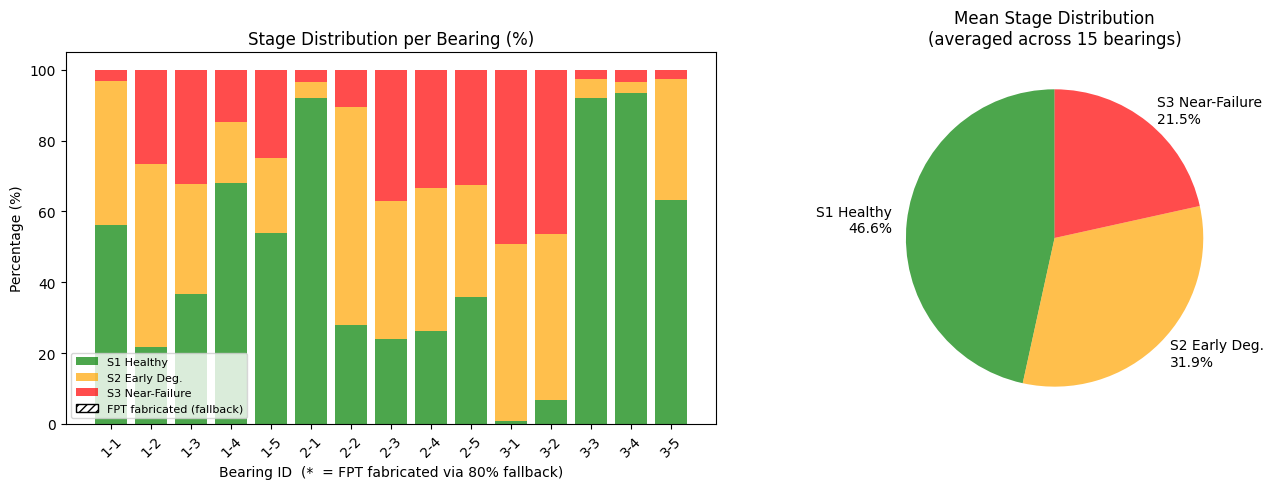

In [7]:
# Per-bearing percentage distribution
per_bearing_pct = []
for bid, r in results.items():
    sc = r['stage_counts']
    total = sc[1] + sc[2] + sc[3]
    short_id = bid.replace('Bearing', '').replace('_', '-')
    per_bearing_pct.append({
        'bearing': short_id,
        'S1_pct': 100 * sc[1] / total,
        'S2_pct': 100 * sc[2] / total,
        'S3_pct': 100 * sc[3] / total,
        'fpt_detected': r['fpt_detected'],   # False = FPT was fabricated (80% fallback)
    })

df_pct = pd.DataFrame(per_bearing_pct)

n_fallback = int((~df_pct['fpt_detected']).sum())
print("Per-bearing stage distribution (%):")
print(df_pct.to_string(index=False))
print()
print(f"MEAN across bearings:")
print(f"  Stage 1 (healthy):       {df_pct['S1_pct'].mean():.1f}% ± {df_pct['S1_pct'].std():.1f}%")
print(f"  Stage 2 (early deg.):    {df_pct['S2_pct'].mean():.1f}% ± {df_pct['S2_pct'].std():.1f}%")
print(f"  Stage 3 (near-failure):  {df_pct['S3_pct'].mean():.1f}% ± {df_pct['S3_pct'].std():.1f}%")
print()
print(f"FPT detected in {len(df_pct) - n_fallback}/{len(df_pct)} bearings "
      f"({n_fallback} used 80%-of-life fallback -> marked * below)")

# Build x-axis labels: append * to bearings whose FPT was fabricated
xlabels = [b + (' *' if not d else '') for b, d in zip(df_pct['bearing'], df_pct['fpt_detected'])]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-bearing stacked percentage bar
axes[0].bar(xlabels, df_pct['S1_pct'], color='green', alpha=0.7, label='S1 Healthy')
axes[0].bar(xlabels, df_pct['S2_pct'], bottom=df_pct['S1_pct'], color='orange', alpha=0.7, label='S2 Early Deg.')
axes[0].bar(xlabels, df_pct['S3_pct'], bottom=df_pct['S1_pct'] + df_pct['S2_pct'], color='red', alpha=0.7, label='S3 Near-Failure')

# Hatch the bars whose FPT was fabricated so they are unmistakable
for i, detected in enumerate(df_pct['fpt_detected']):
    if not detected:
        for container in axes[0].containers:
            container[i].set_hatch('////')
            container[i].set_edgecolor('black')
            container[i].set_linewidth(0.8)

# Colour the fabricated bearings' x tick labels red
for i, detected in enumerate(df_pct['fpt_detected']):
    if not detected:
        axes[0].get_xticklabels()[i].set_color('red')

axes[0].set_xlabel('Bearing ID  (*  = FPT fabricated via 80% fallback)')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Stage Distribution per Bearing (%)')
axes[0].tick_params(axis='x', rotation=45)

# Add a proxy legend entry for the hatch
from matplotlib.patches import Patch
handles, labels = axes[0].get_legend_handles_labels()
handles.append(Patch(facecolor='white', edgecolor='black', hatch='////', label='FPT fabricated (fallback)'))
axes[0].legend(handles=handles, fontsize=8)

# Mean pie chart
mean_pcts = [df_pct['S1_pct'].mean(), df_pct['S2_pct'].mean(), df_pct['S3_pct'].mean()]
axes[1].pie(
    mean_pcts,
    labels=[f'S1 Healthy\n{mean_pcts[0]:.1f}%',
            f'S2 Early Deg.\n{mean_pcts[1]:.1f}%',
            f'S3 Near-Failure\n{mean_pcts[2]:.1f}%'],
    colors=['green', 'orange', 'red'],
    autopct='', startangle=90,
    wedgeprops={'alpha': 0.7}
)
axes[1].set_title('Mean Stage Distribution\n(averaged across 15 bearings)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_stage_distribution_per_bearing_pct.png', dpi=150, bbox_inches='tight')
plt.show()


FPT detected in 15/15 bearings (0 used 80% fallback)


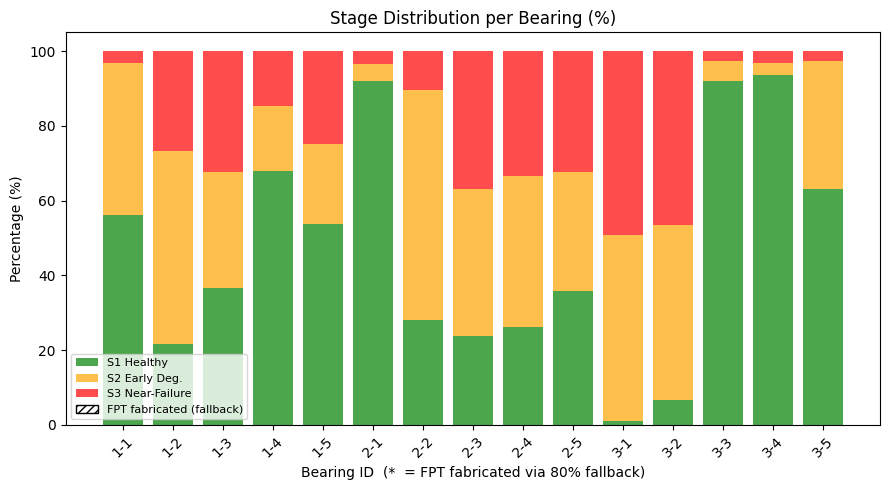

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df_pct = pd.DataFrame([{
    'bearing': bid.replace('Bearing','').replace('_','-'),
    'S1_pct': 100*r['stage_counts'][1]/sum(r['stage_counts'].values()),
    'S2_pct': 100*r['stage_counts'][2]/sum(r['stage_counts'].values()),
    'S3_pct': 100*r['stage_counts'][3]/sum(r['stage_counts'].values()),
    'fpt_detected': r['fpt_detected'],
} for bid, r in results.items()])

n_fb = int((~df_pct['fpt_detected']).sum())
print(f"FPT detected in {len(df_pct)-n_fb}/{len(df_pct)} bearings ({n_fb} used 80% fallback)")
if n_fb:
    print("  Fabricated:", ", ".join(df_pct.loc[~df_pct['fpt_detected'],'bearing']))

xlabels = [b + (' *' if not d else '') for b, d in zip(df_pct['bearing'], df_pct['fpt_detected'])]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(xlabels, df_pct['S1_pct'], color='green', alpha=0.7, label='S1 Healthy')
ax.bar(xlabels, df_pct['S2_pct'], bottom=df_pct['S1_pct'], color='orange', alpha=0.7, label='S2 Early Deg.')
ax.bar(xlabels, df_pct['S3_pct'], bottom=df_pct['S1_pct']+df_pct['S2_pct'], color='red', alpha=0.7, label='S3 Near-Failure')

for i, det in enumerate(df_pct['fpt_detected']):
    if not det:
        for c in ax.containers:
            c[i].set_hatch('////'); c[i].set_edgecolor('black'); c[i].set_linewidth(0.8)
        ax.get_xticklabels()[i].set_color('red')

ax.set_xlabel('Bearing ID  (*  = FPT fabricated via 80% fallback)')
ax.set_ylabel('Percentage (%)')
ax.set_title('Stage Distribution per Bearing (%)')
ax.tick_params(axis='x', rotation=45)
h, _ = ax.get_legend_handles_labels()
h.append(Patch(facecolor='white', edgecolor='black', hatch='////', label='FPT fabricated (fallback)'))
ax.legend(handles=h, fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Multivariate feature matrix preview

Feature matrix shape: (491, 20)
  → 491 time steps × 20 features
  FPT: t=452 | Acc: t=474 | EOL: t=490

Feature names (20):
  [ 0] horiz_rms
  [ 1] horiz_peak
  [ 2] horiz_peak_to_peak
  [ 3] horiz_std
  [ 4] horiz_kurtosis
  [ 5] horiz_skewness
  [ 6] horiz_crest_factor
  [ 7] horiz_shape_factor
  [ 8] horiz_impulse_factor
  [ 9] horiz_clearance_factor
  [10] vert_rms
  [11] vert_peak
  [12] vert_peak_to_peak
  [13] vert_std
  [14] vert_kurtosis
  [15] vert_skewness
  [16] vert_crest_factor
  [17] vert_shape_factor
  [18] vert_impulse_factor
  [19] vert_clearance_factor


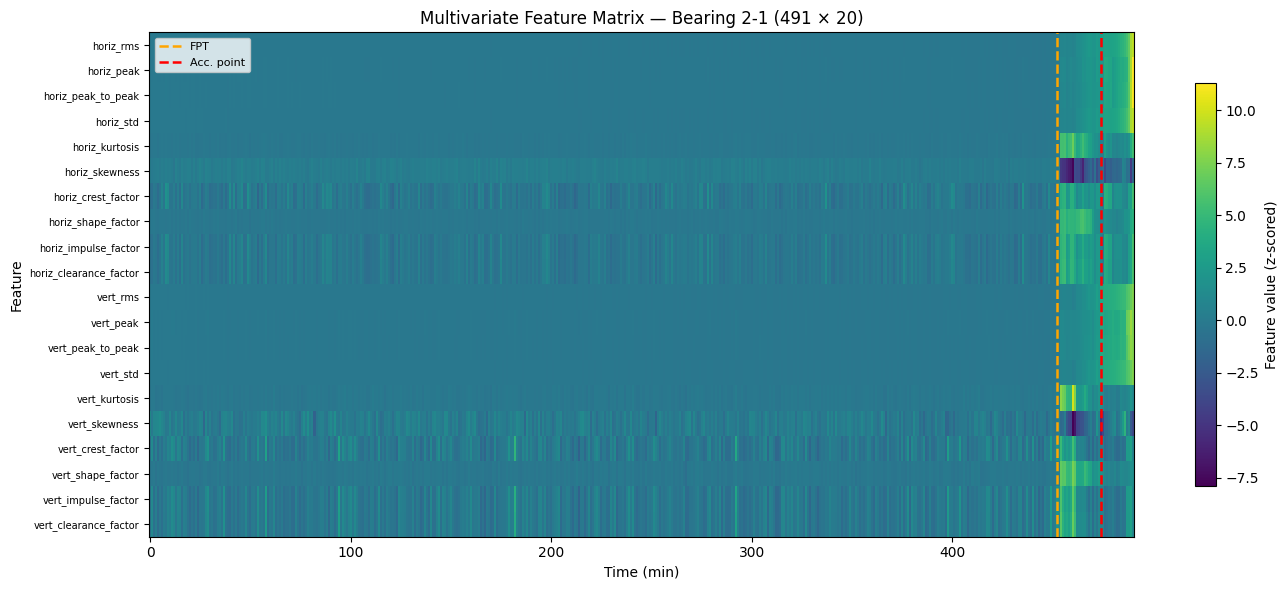

In [12]:
# Show feature matrix for one bearing (short lifetime → sharp degradation bands)
BEARING = 'Bearing2_1'   # short-lived bearing: clear healthy→early→near-failure transitions
r = results[BEARING]
feat_names = r['feature_names']
bid_short = BEARING.replace('Bearing', '').replace('_', '-')

print(f"Feature matrix shape: {r['features'].shape}")
print(f"  → {r['features'].shape[0]} time steps × {r['features'].shape[1]} features")
print(f"  FPT: t={r['fpt_idx']} | Acc: t={r['acc_idx']} | EOL: t={r['eol_idx']}")
print(f"\nFeature names ({len(feat_names)}):")
for i, name in enumerate(feat_names):
    print(f"  [{i:2d}] {name}")

# Z-score each feature (row) so all features share a comparable scale.
# Without this, large-magnitude features dominate and the rest look flat.
F = r['features'].T.astype(float)
F_norm = (F - F.mean(axis=1, keepdims=True)) / (F.std(axis=1, keepdims=True) + 1e-8)

# Heatmap of features over time
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(F_norm, aspect='auto', cmap='viridis', interpolation='nearest')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Feature')
ax.set_yticks(range(len(feat_names)))
ax.set_yticklabels(feat_names, fontsize=7)
ax.set_title(f'Multivariate Feature Matrix — Bearing {bid_short} '
             f'({r["features"].shape[0]} × {r["features"].shape[1]})')

# Mark stage boundaries
ax.axvline(r['fpt_idx'], color='orange', ls='--', lw=1.8, label='FPT')
ax.axvline(r['acc_idx'], color='red', ls='--', lw=1.8, label='Acc. point')
ax.legend(loc='upper left', fontsize=8)

plt.colorbar(im, ax=ax, label='Feature value (z-scored)', shrink=0.8)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_feature_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Feature correlation between channels

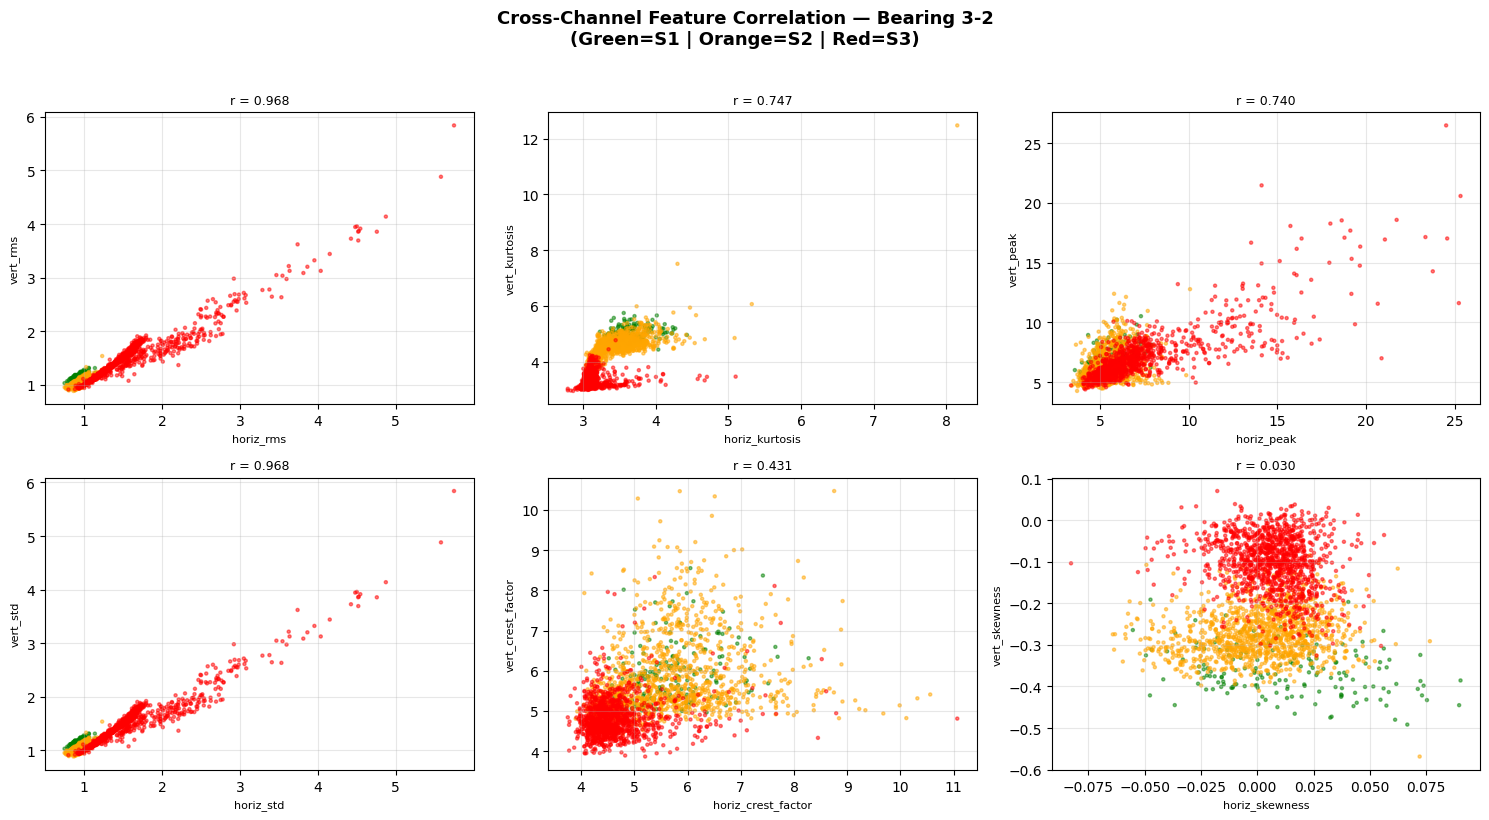

In [10]:
# Show that horizontal and vertical features are correlated but not identical
r = results['Bearing3_2']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_pairs = [
    ('horiz_rms', 'vert_rms', 0, 10),
    ('horiz_kurtosis', 'vert_kurtosis', 4, 14),
    ('horiz_peak', 'vert_peak', 1, 11),
    ('horiz_std', 'vert_std', 3, 13),
    ('horiz_crest_factor', 'vert_crest_factor', 6, 16),
    ('horiz_skewness', 'vert_skewness', 5, 15),
]

for ax, (name_h, name_v, idx_h, idx_v) in zip(axes.flat, feature_pairs):
    stage_colors = ['green' if s == 1 else 'orange' if s == 2 else 'red'
                    for s in r['stage_labels']]
    ax.scatter(r['features'][:, idx_h], r['features'][:, idx_v],
               c=stage_colors, s=5, alpha=0.5)
    corr = np.corrcoef(r['features'][:, idx_h], r['features'][:, idx_v])[0, 1]
    ax.set_xlabel(name_h, fontsize=8)
    ax.set_ylabel(name_v, fontsize=8)
    ax.set_title(f'r = {corr:.3f}', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Cross-Channel Feature Correlation — Bearing 3-2\n'
             '(Green=S1 | Orange=S2 | Red=S3)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_cross_channel_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Summary

In [11]:
print("=" * 60)
print("STEP 2 SUMMARY")
print("=" * 60)
print(f"Health indicator method: simple RMS (horizontal channel)")
print(f"Smoothing window: 3")
print(f"FPT detection: 3-sigma, 2 consecutive exceedances")
print(f"Number of features per time step: {results['Bearing1_1']['features'].shape[1]}")
print(f"Feature names: {get_all_feature_names()}")
print(f"\nGlobal stage distribution:")
for s in [1, 2, 3]:
    pct = 100 * total_stages[s] / total
    print(f"  Stage {s}: {total_stages[s]} ({pct:.1f}%)")
print(f"\nData scarcity ratio (S1:S3): {total_stages[1] / max(total_stages[3], 1):.1f}:1")
print(f"\nFigures saved:")
for f in sorted(os.listdir(SAVE_DIR)):
    if f.startswith('02_'):
        print(f"  {f}")
print("\n✅ Step 2 complete. Proceed to Step 3 (windowing + splits).")

STEP 2 SUMMARY
Health indicator method: simple RMS (horizontal channel)
Smoothing window: 3
FPT detection: 3-sigma, 2 consecutive exceedances
Number of features per time step: 20
Feature names: ['horiz_rms', 'horiz_peak', 'horiz_peak_to_peak', 'horiz_std', 'horiz_kurtosis', 'horiz_skewness', 'horiz_crest_factor', 'horiz_shape_factor', 'horiz_impulse_factor', 'horiz_clearance_factor', 'vert_rms', 'vert_peak', 'vert_peak_to_peak', 'vert_std', 'vert_kurtosis', 'vert_skewness', 'vert_crest_factor', 'vert_shape_factor', 'vert_impulse_factor', 'vert_clearance_factor']

Global stage distribution:
  Stage 1: 3051 (2676.3%)
  Stage 2: 3206 (2812.3%)
  Stage 3: 2959 (2595.6%)

Data scarcity ratio (S1:S3): 1.0:1

Figures saved:
  02_all_bearings_stages.png
  02_cross_channel_correlation.png
  02_feature_matrix_heatmap.png
  02_stage_distribution_per_bearing_pct.png
  02_stage_labels_sample.png

✅ Step 2 complete. Proceed to Step 3 (windowing + splits).
